In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

from torch_geometric.nn.models.tgn import (
    TGNMemory,
    IdentityMessage,
    LastAggregator
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [5]:
data = np.load(
    "nft_graph_dataset.npz",
    allow_pickle=True
)

src = torch.tensor(data["src"], dtype=torch.long)
dst = torch.tensor(data["dst"], dtype=torch.long)
ts = torch.tensor(data["timestamps"], dtype=torch.long)

edge_feat = torch.tensor(
    data["edge_feat"],
    dtype=torch.float32
)

labels = torch.tensor(
    data["labels"],
    dtype=torch.float32
)

train_mask = torch.tensor(data["train_mask"])
val_mask = torch.tensor(data["val_mask"])
test_mask = torch.tensor(data["test_mask"])

num_nodes = int(
    max(src.max(), dst.max())
) + 1

print("Nodes:", num_nodes)
print("Edges:", len(src))
print("Edge Features:", edge_feat.shape[1])

Nodes: 333077
Edges: 2713386
Edge Features: 9


In [6]:
data = np.load(
    "nft_graph_dataset.npz",
    allow_pickle=True
)

src = torch.tensor(data["src"], dtype=torch.long)
dst = torch.tensor(data["dst"], dtype=torch.long)
ts = torch.tensor(data["timestamps"], dtype=torch.long)

edge_feat = torch.tensor(
    data["edge_feat"],
    dtype=torch.float32
)

labels = torch.tensor(
    data["labels"],
    dtype=torch.float32
)

train_mask = torch.tensor(data["train_mask"])
val_mask = torch.tensor(data["val_mask"])
test_mask = torch.tensor(data["test_mask"])

num_nodes = int(
    max(src.max(), dst.max())
) + 1

print("Nodes:", num_nodes)
print("Edges:", len(src))
print("Edge Features:", edge_feat.shape[1])

Nodes: 333077
Edges: 2713386
Edge Features: 9


In [7]:
DEBUG_TRAIN = 140_000
DEBUG_VAL = 30_000
DEBUG_TEST = 30_000

train_idx_full = np.where(train_mask)[0]
val_idx_full = np.where(val_mask)[0]
test_idx_full = np.where(test_mask)[0]

np.random.seed(42)

train_debug = np.random.choice(
    train_idx_full,
    DEBUG_TRAIN,
    replace=False
)

val_debug = np.random.choice(
    val_idx_full,
    DEBUG_VAL,
    replace=False
)

test_debug = np.random.choice(
    test_idx_full,
    DEBUG_TEST,
    replace=False
)

debug_idx = np.concatenate([
    train_debug,
    val_debug,
    test_debug
])

debug_idx = np.sort(debug_idx)

In [8]:
src = src[debug_idx]
dst = dst[debug_idx]
ts = ts[debug_idx]

edge_feat = edge_feat[debug_idx]
labels = labels[debug_idx]

train_mask = train_mask[debug_idx]
val_mask = val_mask[debug_idx]
test_mask = test_mask[debug_idx]

print("Dataset:", len(src))
print("Train:", train_mask.sum())
print("Val:", val_mask.sum())
print("Test:", test_mask.sum())

Dataset: 200000
Train: tensor(140000)
Val: tensor(30000)
Test: tensor(30000)


In [9]:
memory_dim = 100
time_dim = 100

memory = TGNMemory(
    num_nodes=num_nodes,
    raw_msg_dim=edge_feat.shape[1],
    memory_dim=memory_dim,
    time_dim=time_dim,
    message_module=IdentityMessage(
        edge_feat.shape[1],
        memory_dim,
        time_dim
    ),
    aggregator_module=LastAggregator()
).to(DEVICE)

print(memory)

TGNMemory(
  (msg_s_module): IdentityMessage()
  (msg_d_module): IdentityMessage()
  (aggr_module): LastAggregator()
  (time_enc): TimeEncoder(
    (lin): Linear(in_features=1, out_features=100, bias=True)
  )
  (gru): GRUCell(309, 100)
)


In [10]:
class EdgePredictor(nn.Module):

    def __init__(
        self,
        memory_dim,
        edge_dim
    ):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(
                memory_dim * 2 + edge_dim,
                128
            ),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(
        self,
        z_src,
        z_dst,
        edge_feat
    ):
        x = torch.cat(
            [z_src, z_dst, edge_feat],
            dim=1
        )

        return self.mlp(x).squeeze(-1)


predictor = EdgePredictor(
    memory_dim=memory_dim,
    edge_dim=edge_feat.shape[1]
).to(DEVICE)

print(predictor)

EdgePredictor(
  (mlp): Sequential(
    (0): Linear(in_features=209, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [11]:
optimizer = optim.Adam(
    list(memory.parameters()) +
    list(predictor.parameters()),
    lr=1e-3
)

criterion = nn.BCEWithLogitsLoss()

In [12]:
def train_epoch():

    memory.train()
    predictor.train()

    memory.reset_state()

    train_idx = np.where(
        train_mask
    )[0]

    total_loss = 0

    for step, i in enumerate(train_idx):

        s = src[i].unsqueeze(0).to(DEVICE)
        d = dst[i].unsqueeze(0).to(DEVICE)
        t = ts[i].unsqueeze(0).to(DEVICE)

        x = edge_feat[i].unsqueeze(0).to(DEVICE)
        y = labels[i].unsqueeze(0).to(DEVICE)

        n_id = torch.unique(
            torch.cat([s, d])
        )

        z, _ = memory(n_id)

        z = z.detach()

        z_src = z[
            (n_id == s)
            .nonzero(as_tuple=True)[0]
        ]

        z_dst = z[
            (n_id == d)
            .nonzero(as_tuple=True)[0]
        ]

        pred = predictor(
            z_src,
            z_dst,
            x
        )

        loss = criterion(pred, y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        memory.update_state(
            s,
            d,
            t,
            x
        )

        total_loss += loss.item()

        if step % 10000 == 0:

            print(
                f"step {step}/{len(train_idx)} "
                f"loss={loss.item():.4f}"
            )

    return total_loss / len(train_idx)

In [13]:
loss = train_epoch()

print("Epoch Loss:", loss)

step 0/140000 loss=0.6849
step 10000/140000 loss=0.0008
step 20000/140000 loss=0.0000
step 30000/140000 loss=0.0000
step 40000/140000 loss=0.0116
step 50000/140000 loss=0.0000
step 60000/140000 loss=0.0024
step 70000/140000 loss=0.0580
step 80000/140000 loss=0.0015
step 90000/140000 loss=0.0000
step 100000/140000 loss=0.0000
step 110000/140000 loss=0.0000
step 120000/140000 loss=0.0000
step 130000/140000 loss=0.0000
Epoch Loss: 0.039751492010255116


In [14]:
memory.eval()
predictor.eval()

all_pred = []
all_y = []

test_idx = np.where(
    test_mask
)[0]

with torch.no_grad():

    for i in test_idx:

        s = src[i].unsqueeze(0).to(DEVICE)
        d = dst[i].unsqueeze(0).to(DEVICE)

        x = edge_feat[i].unsqueeze(0).to(DEVICE)

        n_id = torch.unique(
            torch.cat([s, d])
        )

        z, _ = memory(n_id)

        z_src = z[
            (n_id == s)
            .nonzero(as_tuple=True)[0]
        ]

        z_dst = z[
            (n_id == d)
            .nonzero(as_tuple=True)[0]
        ]

        pred = predictor(
            z_src,
            z_dst,
            x
        )

        all_pred.append(
            torch.sigmoid(pred)
            .cpu()
            .item()
        )

        all_y.append(
            labels[i].item()
        )

print(
    "ROC-AUC:",
    roc_auc_score(
        all_y,
        all_pred
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        all_y,
        all_pred
    )
)

ROC-AUC: 0.8820203823214965
PR-AUC: 0.2766079963312578


In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

memory.eval()
predictor.eval()

all_pred = []
all_y = []

test_idx = np.where(test_mask)[0]

with torch.no_grad():

    for i in test_idx:

        s = src[i].unsqueeze(0).to(DEVICE)
        d = dst[i].unsqueeze(0).to(DEVICE)

        x = edge_feat[i].unsqueeze(0).to(DEVICE)

        n_id = torch.unique(torch.cat([s, d]))

        z, _ = memory(n_id)

        z_src = z[(n_id == s).nonzero(as_tuple=True)[0]]
        z_dst = z[(n_id == d).nonzero(as_tuple=True)[0]]

        pred = predictor(z_src, z_dst, x)

        all_pred.append(
            torch.sigmoid(pred).cpu().item()
        )

        all_y.append(
            labels[i].item()
        )

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

pred_label = (np.array(all_pred) >= 0.5).astype(int)

print(confusion_matrix(all_y, pred_label))

print(
    classification_report(
        all_y,
        pred_label,
        digits=4
    )
)

[[29889     0]
 [  111     0]]
              precision    recall  f1-score   support

         0.0     0.9963    1.0000    0.9981     29889
         1.0     0.0000    0.0000    0.0000       111

    accuracy                         0.9963     30000
   macro avg     0.4981    0.5000    0.4991     30000
weighted avg     0.9926    0.9963    0.9945     30000



c:\Users\aryak\anaconda3\envs\nft-research\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aryak\anaconda3\envs\nft-research\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aryak\anaconda3\envs\nft-research\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [17]:
preds = np.array(all_pred)

print("Min :", preds.min())
print("Max :", preds.max())
print("Mean:", preds.mean())

for q in [0.5, 0.9, 0.95, 0.99, 0.999]:
    print(
        q,
        np.quantile(preds, q)
    )

Min : 3.3331047340559583e-13
Max : 0.041366152465343475
Mean: 2.0480183762882847e-05
0.5 1.8669241264035463e-08
0.9 2.8472581334426707e-06
0.95 1.397338123751978e-05
0.99 0.0004697953280992799
0.999 0.0023763055736199116


In [18]:
preds = np.array(all_pred)
y = np.array(all_y)

print(
    "Fraud mean:",
    preds[y == 1].mean()
)

print(
    "Normal mean:",
    preds[y == 0].mean()
)

print(
    "Fraud median:",
    np.median(preds[y == 1])
)

print(
    "Normal median:",
    np.median(preds[y == 0])
)

Fraud mean: 0.0017434255292553872
Normal mean: 1.4081611266323309e-05
Fraud median: 0.0006314985803328454
Normal median: 1.842019337061629e-08


In [19]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    all_y,
    all_pred
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

best_idx = np.argmax(f1_scores)

print("Best Threshold :", thresholds[best_idx])
print("Best Precision :", precision[best_idx])
print("Best Recall    :", recall[best_idx])
print("Best F1        :", f1_scores[best_idx])

Best Threshold : 0.0009446672047488391
Best Precision : 0.375
Best Recall    : 0.43243243243243246
Best F1        : 0.40167364011761697


In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

best_threshold = thresholds[best_idx]

pred_label = (
    np.array(all_pred)
    >= best_threshold
).astype(int)

print(
    confusion_matrix(
        all_y,
        pred_label
    )
)

print(
    classification_report(
        all_y,
        pred_label,
        digits=4
    )
)

[[29809    80]
 [   63    48]]
              precision    recall  f1-score   support

         0.0     0.9979    0.9973    0.9976     29889
         1.0     0.3750    0.4324    0.4017       111

    accuracy                         0.9952     30000
   macro avg     0.6864    0.7149    0.6996     30000
weighted avg     0.9956    0.9952    0.9954     30000



In [21]:
fraud_count = labels[train_mask == 1].sum().item()

normal_count = (
    train_mask.sum().item()
    - fraud_count
)

print("Normal:", normal_count)
print("Fraud :", fraud_count)

print(
    "Pos Weight:",
    normal_count / fraud_count
)

Normal: 138816.0
Fraud : 1184.0
Pos Weight: 117.24324324324324


In [22]:
# ====================================
# EXPERIMENT 2
# TGN + Weighted BCE
# ====================================

In [23]:
normal_count = (
    labels[train_mask] == 0
).sum().item()

fraud_count = (
    labels[train_mask] == 1
).sum().item()

print("Normal:", normal_count)
print("Fraud :", fraud_count)

pos_weight = torch.tensor(
    [normal_count / fraud_count],
    device=DEVICE
)

print("Pos Weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

Normal: 138816
Fraud : 1184
Pos Weight: 117.24324035644531


In [24]:
memory = TGNMemory(
    num_nodes=num_nodes,
    raw_msg_dim=edge_feat.shape[1],
    memory_dim=memory_dim,
    time_dim=time_dim,
    message_module=IdentityMessage(
        edge_feat.shape[1],
        memory_dim,
        time_dim
    ),
    aggregator_module=LastAggregator()
).to(DEVICE)

predictor = EdgePredictor(
    memory_dim=memory_dim,
    edge_dim=edge_feat.shape[1]
).to(DEVICE)

optimizer = optim.Adam(
    list(memory.parameters()) +
    list(predictor.parameters()),
    lr=1e-3
)

print("Model reset complete")

Model reset complete


In [25]:
loss = train_epoch()

print("Epoch Loss:", loss)

step 0/140000 loss=0.8709
step 10000/140000 loss=6.4564
step 20000/140000 loss=29.0315
step 30000/140000 loss=3.8688
step 40000/140000 loss=4.5189
step 50000/140000 loss=0.0000
step 60000/140000 loss=0.6182
step 70000/140000 loss=0.0000
step 80000/140000 loss=0.0000
step 90000/140000 loss=0.0000
step 100000/140000 loss=0.0000
step 110000/140000 loss=0.0002
step 120000/140000 loss=0.0374
step 130000/140000 loss=0.0337
Epoch Loss: 10.568781651905976


In [26]:
memory.eval()
predictor.eval()

all_pred = []
all_y = []

test_idx = np.where(test_mask)[0]

with torch.no_grad():

    for i in test_idx:

        s = src[i].unsqueeze(0).to(DEVICE)
        d = dst[i].unsqueeze(0).to(DEVICE)

        x = edge_feat[i].unsqueeze(0).to(DEVICE)

        n_id = torch.unique(torch.cat([s, d]))

        z, _ = memory(n_id)

        z_src = z[(n_id == s).nonzero(as_tuple=True)[0]]
        z_dst = z[(n_id == d).nonzero(as_tuple=True)[0]]

        pred = predictor(z_src, z_dst, x)

        all_pred.append(
            torch.sigmoid(pred).cpu().item()
        )

        all_y.append(
            labels[i].item()
        )

In [27]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print(
    "ROC-AUC:",
    roc_auc_score(all_y, all_pred)
)

print(
    "PR-AUC:",
    average_precision_score(all_y, all_pred)
)

ROC-AUC: 0.7435324514517528
PR-AUC: 0.05189544042938019


In [28]:
import numpy as np

scores = np.array(all_pred)
labels_np = np.array(all_y)

print("Min :", scores.min())
print("Max :", scores.max())
print("Mean:", scores.mean())

for q in [0.5, 0.9, 0.95, 0.99, 0.999]:
    print(
        q,
        np.quantile(scores, q)
    )

fraud_scores = scores[
    labels_np == 1
]

normal_scores = scores[
    labels_np == 0
]

print()
print("Fraud mean :", fraud_scores.mean())
print("Normal mean:", normal_scores.mean())

print("Fraud median :", np.median(fraud_scores))
print("Normal median:", np.median(normal_scores))

Min : 4.0405473411553317e-10
Max : 0.655170738697052
Mean: 0.12547774242870277
0.5 0.12824783474206924
0.9 0.23455719649791718
0.95 0.23455719649791718
0.99 0.23455719649791718
0.999 0.23455719649791718

Fraud mean : 0.21337382761323154
Normal mean: 0.12515131914737912
Fraud median : 0.23455719649791718
Normal median: 0.1273426115512848


In [29]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

best_threshold = None
best_f1 = 0

for threshold in np.linspace(
    0.001,
    0.999,
    1000
):

    pred_label = (
        np.array(all_pred) >= threshold
    ).astype(int)

    f1 = f1_score(
        all_y,
        pred_label,
        zero_division=0
    )

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = threshold

        best_precision = precision_score(
            all_y,
            pred_label,
            zero_division=0
        )

        best_recall = recall_score(
            all_y,
            pred_label,
            zero_division=0
        )

print("Best Threshold :", best_threshold)
print("Best Precision :", best_precision)
print("Best Recall    :", best_recall)
print("Best F1        :", best_f1)

Best Threshold : 0.23476576576576577
Best Precision : 0.7777777777777778
Best Recall    : 0.06306306306306306
Best F1        : 0.11666666666666667


In [30]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

final_pred = (
    np.array(all_pred) >= best_threshold
).astype(int)

print(
    confusion_matrix(
        all_y,
        final_pred
    )
)

print(
    classification_report(
        all_y,
        final_pred,
        digits=4
    )
)

[[29887     2]
 [  104     7]]
              precision    recall  f1-score   support

         0.0     0.9965    0.9999    0.9982     29889
         1.0     0.7778    0.0631    0.1167       111

    accuracy                         0.9965     30000
   macro avg     0.8872    0.5315    0.5574     30000
weighted avg     0.9957    0.9965    0.9950     30000



3 Focal Loss

In [31]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.75,
        gamma=2.0
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(
        self,
        logits,
        targets
    ):

        bce = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(
            targets == 1,
            probs,
            1 - probs
        )

        focal_weight = (
            self.alpha *
            (1 - pt) ** self.gamma
        )

        loss = focal_weight * bce

        return loss.mean()

In [32]:
memory = TGNMemory(
    num_nodes=num_nodes,
    raw_msg_dim=edge_feat.shape[1],
    memory_dim=memory_dim,
    time_dim=time_dim,
    message_module=IdentityMessage(
        edge_feat.shape[1],
        memory_dim,
        time_dim
    ),
    aggregator_module=LastAggregator()
).to(DEVICE)

predictor = EdgePredictor(
    memory_dim=memory_dim,
    edge_dim=edge_feat.shape[1]
).to(DEVICE)

optimizer = optim.Adam(
    list(memory.parameters()) +
    list(predictor.parameters()),
    lr=1e-3
)

In [33]:
criterion = FocalLoss(
    alpha=0.75,
    gamma=2.0
)

In [34]:
loss = train_epoch()

print("Epoch Loss:", loss)

step 0/140000 loss=0.2106
step 10000/140000 loss=0.0002
step 20000/140000 loss=0.0000
step 30000/140000 loss=0.0000
step 40000/140000 loss=0.0005
step 50000/140000 loss=0.0000
step 60000/140000 loss=0.0014
step 70000/140000 loss=0.0000
step 80000/140000 loss=0.0000
step 90000/140000 loss=0.0000
step 100000/140000 loss=0.0008
step 110000/140000 loss=0.0000
step 120000/140000 loss=0.0006
step 130000/140000 loss=0.0000
Epoch Loss: 0.010955813804303943


In [35]:
memory.eval()
predictor.eval()

all_pred = []
all_y = []

test_idx = np.where(test_mask)[0]

with torch.no_grad():

    for i in test_idx:

        s = src[i].unsqueeze(0).to(DEVICE)
        d = dst[i].unsqueeze(0).to(DEVICE)

        x = edge_feat[i].unsqueeze(0).to(DEVICE)

        n_id = torch.unique(torch.cat([s, d]))

        z, _ = memory(n_id)

        z_src = z[(n_id == s).nonzero(as_tuple=True)[0]]
        z_dst = z[(n_id == d).nonzero(as_tuple=True)[0]]

        pred = predictor(z_src, z_dst, x)

        all_pred.append(
            torch.sigmoid(pred).cpu().item()
        )

        all_y.append(
            labels[i].item()
        )

In [36]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print(
    "ROC-AUC:",
    roc_auc_score(all_y, all_pred)
)

print(
    "PR-AUC:",
    average_precision_score(all_y, all_pred)
)

ROC-AUC: 0.7688254348898733
PR-AUC: 0.013075950692214131


In [37]:
import numpy as np

scores = np.array(all_pred)
labels_np = np.array(all_y)

print("Min :", scores.min())
print("Max :", scores.max())
print("Mean:", scores.mean())

for q in [0.5, 0.9, 0.95, 0.99, 0.999]:
    print(
        q,
        np.quantile(scores, q)
    )

fraud_scores = scores[
    labels_np == 1
]

normal_scores = scores[
    labels_np == 0
]

print()
print("Fraud mean :", fraud_scores.mean())
print("Normal mean:", normal_scores.mean())

print("Fraud median :", np.median(fraud_scores))
print("Normal median:", np.median(normal_scores))

Min : 0.0005629486404359341
Max : 0.10779997706413269
Mean: 0.036470099051913715
0.5 0.03538483753800392
0.9 0.060298440232872966
0.95 0.06465014703571796
0.99 0.09133146129548514
0.999 0.10712415724992752

Fraud mean : 0.05404159381381563
Normal mean: 0.03640484307417705
Fraud median : 0.059974826872348785
Normal median: 0.03526429831981659


In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

best_threshold = None
best_f1 = 0

for threshold in np.linspace(
    0.001,
    0.999,
    1000
):

    pred_label = (
        np.array(all_pred) >= threshold
    ).astype(int)

    f1 = f1_score(
        all_y,
        pred_label,
        zero_division=0
    )

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = threshold

        best_precision = precision_score(
            all_y,
            pred_label,
            zero_division=0
        )

        best_recall = recall_score(
            all_y,
            pred_label,
            zero_division=0
        )

print("Best Threshold :", best_threshold)
print("Best Precision :", best_precision)
print("Best Recall    :", best_recall)
print("Best F1        :", best_f1)

Best Threshold : 0.06293793793793794
Best Precision : 0.020429009193054137
Best Recall    : 0.36036036036036034
Best F1        : 0.03866602223296278


In [39]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

final_pred = (
    np.array(all_pred) >= best_threshold
).astype(int)

print(
    confusion_matrix(
        all_y,
        final_pred
    )
)

print(
    classification_report(
        all_y,
        final_pred,
        digits=4
    )
)

[[27971  1918]
 [   71    40]]
              precision    recall  f1-score   support

         0.0     0.9975    0.9358    0.9657     29889
         1.0     0.0204    0.3604    0.0387       111

    accuracy                         0.9337     30000
   macro avg     0.5089    0.6481    0.5022     30000
weighted avg     0.9939    0.9337    0.9622     30000



In [40]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

thresholds = np.linspace(
    0.0001,
    0.20,
    1000
)

target_recall = 0.80

for th in thresholds:

    pred = (
        np.array(all_pred) >= th
    ).astype(int)

    rec = recall_score(
        all_y,
        pred,
        zero_division=0
    )

    if rec >= target_recall:

        prec = precision_score(
            all_y,
            pred,
            zero_division=0
        )

        print("Threshold:", th)
        print("Recall:", rec)
        print("Precision:", prec)

        break

Threshold: 0.0001
Recall: 1.0
Precision: 0.0037


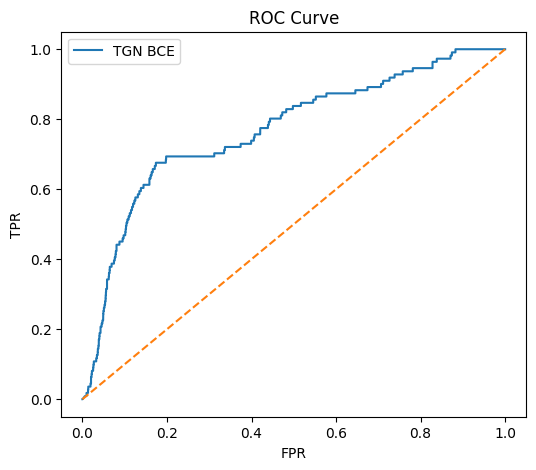

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    all_y,
    all_pred
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="TGN BCE"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.legend()

plt.show()

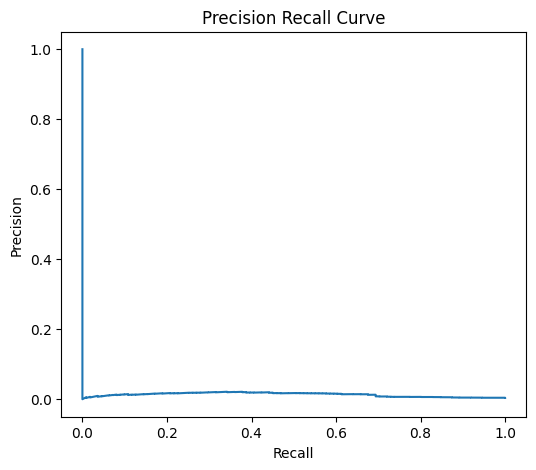

In [42]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(
    all_y,
    all_pred
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [43]:
scores = np.array(all_pred)
y_true = np.array(all_y)

order = np.argsort(scores)[::-1]

for pct in [1, 5, 10]:

    k = int(
        len(scores) *
        pct / 100
    )

    selected = order[:k]

    found = y_true[selected].sum()

    total = y_true.sum()

    print(
        f"Top {pct}% -> "
        f"{found}/{total} fraud found "
        f"({found/total:.3f})"
    )

Top 1% -> 2.0/111.0 fraud found (0.018)
Top 5% -> 27.0/111.0 fraud found (0.243)
Top 10% -> 52.0/111.0 fraud found (0.468)
